In [1]:
import sys
from os.path import dirname

sys.path.append("../src/")

In [2]:
import multiprocessing as mp

# Установка метода spawn (обязательно до любого импорта torch/cuda)
mp.set_start_method("spawn", force=True)

import copy
from collections import Counter, defaultdict
from typing import List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pysam
import scipy as spy
import seaborn as sns
import sklearn as sk
import torch
from ExoModel.exo_model import ExoModel

# from NucDPosITv2.em_nuc_model import CoordinateProbs, EMTorch
from nuc_template_constants import ExoNucTemplate
from scipy.stats import gaussian_kde
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

# from ExoModel.exo_model import calculate_template_length_distribution

/trinity/home/d_ryabov/.conda/envs/newNucDPosIT/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
BAM_PATH = "../data/reads/D_melanogaster_mnase/SRR8766784/SRR8766784.sorted_bam"
BAM_FILE = pysam.AlignmentFile(BAM_PATH)

In [4]:
def calculate_template_length_distribution(bam_file, log_iter=1000000):
    # Открываем BAM файл
    bam = pysam.AlignmentFile(bam_file, "rb")

    # Словарь для хранения распределения длин
    length_dist = Counter()
    total_pairs = 0

    # Проходим по всем выравниваниям
    for read in bam:
        # Проверяем, что read является парным и правильно выровненным
        if read.is_paired and read.is_proper_pair and read.template_length > 0:
            # Берем абсолютное значение длины шаблона
            tl = read.template_length
            length_dist[tl] += 1
            total_pairs += 1
            if total_pairs % log_iter == 0:
                print(f"processed {total_pairs} reads")

    bam.close()
    return length_dist, total_pairs

In [5]:
tlens, all_counts = calculate_template_length_distribution(BAM_PATH)
hist = np.array([tlens[i] / all_counts for i in range(0, 599)])
hist = hist / hist.sum()

processed 1000000 reads
processed 2000000 reads
processed 3000000 reads
processed 4000000 reads
processed 5000000 reads
processed 6000000 reads
processed 7000000 reads
processed 8000000 reads
processed 9000000 reads
processed 10000000 reads
processed 11000000 reads
processed 12000000 reads
processed 13000000 reads
processed 14000000 reads
processed 15000000 reads


np.int64(170)

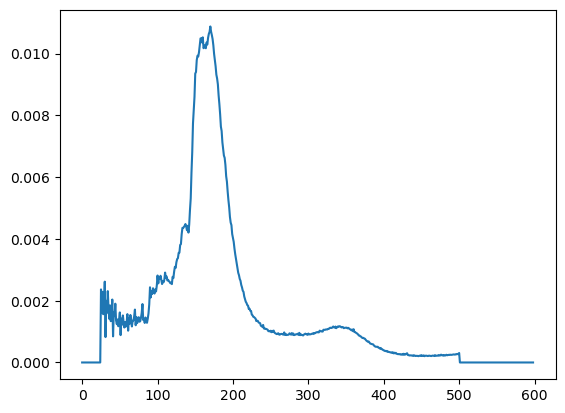

In [6]:
plt.plot(hist)
np.argmax(hist)

In [32]:
import warnings
from functools import partial
from multiprocessing import Pool, cpu_count

import matplotlib.pyplot as plt
import numpy as np
import scipy as spy
from scipy.optimize import OptimizeResult
from tqdm.auto import tqdm


class HistogramDeconvolution:
    """
    Базовый класс для деконволюции гистограммы

    Parameters:
    -----------
    hist : np.ndarray
        Входная гистограмма
    lamb : float
        Параметр регуляризации
    center_loc : float
        Локация центра для инициализации (mean для нормального распределения)
    center_scale : float
        Масштаб для инициализации (std для нормального распределения)
    """

    def __init__(self, hist, lamb=14, center_loc=73, center_scale=10):
        self.hist = hist
        self.lamb = lamb
        self.center_loc = center_loc
        self.center_scale = center_scale

        # Подготовка данных
        self.Q = hist.reshape(-1, 1)
        self.N = len(self.Q)
        self.k = self.N // 2 + 1

        # Инициализация
        self.P_init = None
        self.weights = None
        self.center = None
        self.result = None

        self._initialize_parameters()

    def _initialize_parameters(self):
        """Инициализация параметров P_init и весов"""
        # Начальное приближение P (нормальное распределение)
        x = np.arange(0, self.k, 1)
        self.P_init = spy.stats.norm.pdf(
            x, loc=self.center_loc, scale=self.center_scale
        )
        self.P_init /= self.P_init.sum()

        # Вычисление центра и весов для регуляризации
        self.center = np.argmax(self.Q) // 2
        x = np.arange(0, self.k)
        weights = (self.center - x) ** 2
        self.weights = weights / np.max(weights)

    def loss(self, P):
        """
        Функция потерь с регуляризацией

        Parameters:
        -----------
        P : np.ndarray
            Вектор вероятностей

        Returns:
        --------
        float : Значение функции потерь
        """
        reg = self.lamb * np.dot(P**2, self.weights)
        loss = np.sum((self.Q - np.convolve(P, P).reshape(-1, 1)) ** 2) + reg
        return loss

    def fit(self, method="SLSQP", tol=1e-30, maxiter=1000, **kwargs):
        """
        Выполняет оптимизацию для нахождения P

        Parameters:
        -----------
        method : str
            Метод оптимизации (по умолчанию 'SLSQP')
        tol : float
            Толерантность оптимизации
        **kwargs : dict
            Дополнительные аргументы для scipy.optimize.minimize

        Returns:
        --------
        OptimizeResult : Результат оптимизации
        """
        # Границы: каждый элемент P в [0, 1]
        bounds = [(0, 1) for _ in range(self.k)]

        # Ограничение: сумма P равна 1
        constraints = {"type": "eq", "fun": lambda p: np.sum(p) - 1}

        # Оптимизация
        self.result = spy.optimize.minimize(
            self.loss,
            bounds=bounds,
            x0=self.P_init,
            method=method,
            constraints=constraints,
            options={"maxiter": maxiter},
            tol=tol,
            **kwargs,
        )

        return self.result

    def get_deconvolved(self):
        """
        Возвращает деконволюированное распределение P
        """
        if self.result is None:
            raise ValueError("Model not fitted yet. Call fit() first.")
        return self.result.x

    def get_reconstructed_hist(self):
        """
        Возвращает реконструированную гистограмму (свертку P с самим собой)
        """
        if self.result is None:
            raise ValueError("Model not fitted yet. Call fit() first.")
        return np.convolve(self.result.x, self.result.x)

    def plot(self, figsize=(16, 9)):
        """
        Визуализирует результаты деконволюции

        Parameters:
        -----------
        figsize : tuple
            Размер фигуры
        """
        if self.result is None:
            raise ValueError("Model not fitted yet. Call fit() first.")

        fig, axs = plt.subplots(1, 2, figsize=figsize)

        # График P (деконволюированное распределение)
        axs[0].plot(self.result.x, linewidth=2)
        axs[0].set_title("Deconvolved Distribution P", fontsize=14)
        axs[0].set_xlabel("Index", fontsize=12)
        axs[0].set_ylabel("Probability", fontsize=12)
        axs[0].grid(True, alpha=0.3)

        # Сравнение модельной и экспериментальной гистограмм
        axs[1].plot(self.get_reconstructed_hist(), label="Model (P * P)", linewidth=2)
        axs[1].plot(self.hist, label="Experimental", linewidth=2, alpha=0.7)
        axs[1].set_title("Histogram Comparison", fontsize=14)
        axs[1].set_xlabel("Index", fontsize=12)
        axs[1].set_ylabel("Counts", fontsize=12)
        axs[1].legend(fontsize=12)
        axs[1].grid(True, alpha=0.3)

        plt.tight_layout()
        return fig, axs

    def summary(self):
        """
        Выводит сводку результатов оптимизации
        """
        if self.result is None:
            print("Model not fitted yet. Call fit() first.")
            return

        print("=" * 60)
        print("DECONVOLUTION RESULTS")
        print("=" * 60)
        print(f"Success: {self.result.success}")
        print(f"Message: {self.result.message}")
        print(f"Number of iterations: {self.result.nit}")
        print(f"Final loss: {self.result.fun:.6f}")
        print(f"Lambda (regularization): {self.lamb}")
        print(f"Sum of P: {np.sum(self.result.x):.6f}")
        print(f"Max P value: {np.max(self.result.x):.6f}")
        print(f"Min P value: {np.min(self.result.x):.6f}")
        print("=" * 60)


class AdaptiveHistogramDeconvolution(HistogramDeconvolution):
    """
    Класс для автоматического подбора параметра lamb с использованием мультипроцессинга

    Parameters:
    -----------
    hist : np.ndarray
        Входная гистограмма
    lamb_range : tuple
        Диапазон для подбора параметра регуляризации (min, max)
    n_jobs : int
        Количество процессов для параллельного выполнения (-1 для всех доступных ядер)
    **kwargs : dict
        Дополнительные аргументы для HistogramDeconvolution
    """

    def __init__(self, hist, lamb_range=(1, 50), n_jobs=-1, **kwargs):
        super().__init__(hist, **kwargs)
        self.lamb_range = lamb_range
        self.n_jobs = n_jobs if n_jobs != -1 else cpu_count()
        print(self.n_jobs)
        self.best_lamb = None
        self.best_result = None
        self.all_results = []

    @staticmethod
    def _evaluate_lamb(lamb, hist, center_loc, center_scale, method, tol):
        """
        Статический метод для оценки одного значения lamb
        (необходим для мультипроцессинга)
        """
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                model = HistogramDeconvolution(
                    hist=hist,
                    lamb=lamb,
                    center_loc=center_loc,
                    center_scale=center_scale,
                )
                result = model.fit(method=method, tol=tol)

                return {
                    "lamb": lamb,
                    "loss": result.fun,
                    "success": result.success,
                    "nit": result.nit,
                    "message": result.message,
                    "result_x": result.x,
                    "reconstructed": model.get_reconstructed_hist(),
                }
        except Exception as e:
            return {
                "lamb": lamb,
                "loss": np.inf,
                "success": False,
                "error": str(e),
                "message": f"Failed: {str(e)}",
            }

    def grid_search(self, n_lamb=20, verbose=True, parallel=True):
        """
        Выполняет поиск по сетке для подбора оптимального параметра lamb

        Parameters:
        -----------
        n_lamb : int
            Количество значений lambda
        verbose : bool
            Печатать ли прогресс
        parallel : bool
            Использовать ли параллельное выполнение

        Returns:
        --------
        dict : Лучшие параметры
        """
        lamb_values = np.linspace(self.lamb_range[0], self.lamb_range[1], n_lamb)

        if verbose:
            print(f"Starting grid search with {len(lamb_values)} lambda values")
            print(f"Lambda range: [{self.lamb_range[0]:.2f}, {self.lamb_range[1]:.2f}]")
            print(f"Using {self.n_jobs if parallel else 1} processes")
            print("-" * 60)

            with Pool(processes=self.n_jobs) as pool:
                # Создаем частичную функцию с фиксированными аргументами
                eval_func = partial(
                    self._evaluate_lamb,
                    hist=self.hist,
                    center_loc=self.center_loc,
                    center_scale=self.center_scale,
                    method="SLSQP",
                    tol=1e-30,
                )

                # Запускаем параллельные вычисления
                if verbose:
                    results = list(
                        tqdm(
                            pool.imap(eval_func, lamb_values),
                            total=len(lamb_values),
                            desc="Grid search",
                        )
                    )
                else:
                    results = pool.map(eval_func, lamb_values)

        # Сохраняем все результаты
        self.all_results = results

        # Находим лучший результат
        valid_results = [r for r in results if r["success"] and np.isfinite(r["loss"])]

        if not valid_results:
            print("Warning: No successful optimizations found!")
            return None

        best = min(valid_results, key=lambda x: x["loss"])

        self.best_lamb = best["lamb"]
        self.best_result = best

        if verbose:
            print("-" * 60)
            print(f"Best lambda found: {best['lamb']:.4f}")
            print(f"Best loss: {best['loss']:.6f}")
            print(f"Iterations: {best['nit']}")
            print("-" * 60)

        return {"lamb": self.best_lamb}

    def plot_results(self, figsize=(16, 10)):
        """
        Визуализирует результаты поиска

        Parameters:
        -----------
        figsize : tuple
            Размер фигуры
        """
        if not self.all_results:
            print("No results to plot. Run grid_search() or random_search() first.")
            return

        fig, axes = plt.subplots(2, 2, figsize=figsize)

        # 1. Зависимость loss от lambda
        lambdas = [r["lamb"] for r in self.all_results]
        losses = [r["loss"] for r in self.all_results]

        # Сортируем по lambda
        sorted_indices = np.argsort(lambdas)
        lambdas_sorted = np.array(lambdas)[sorted_indices]
        losses_sorted = np.array(losses)[sorted_indices]

        axes[0, 0].plot(lambdas_sorted, losses_sorted, "b-o", linewidth=2, markersize=6)
        axes[0, 0].set_xlabel("Lambda", fontsize=12)
        axes[0, 0].set_ylabel("Loss", fontsize=12)
        axes[0, 0].set_title("Loss vs Lambda", fontsize=14)
        axes[0, 0].grid(True, alpha=0.3)

        # Отмечаем лучший результат
        best_idx = np.argmin(losses)
        axes[0, 0].plot(
            lambdas[best_idx],
            losses[best_idx],
            "r*",
            markersize=15,
            label=f"Best: λ={lambdas[best_idx]:.3f}, loss={losses[best_idx]:.4f}",
        )
        axes[0, 0].legend()

        # 2. Scatter plot
        scatter = axes[0, 1].scatter(
            lambdas,
            losses,
            c=losses,
            cmap="viridis",
            s=80,
            alpha=0.6,
            edgecolors="black",
            linewidth=1,
        )
        axes[0, 1].set_xlabel("Lambda", fontsize=12)
        axes[0, 1].set_ylabel("Loss", fontsize=12)
        axes[0, 1].set_title("Loss Distribution", fontsize=14)
        axes[0, 1].grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=axes[0, 1], label="Loss")

        # 3. Гистограмма потерь
        axes[1, 0].hist(losses, bins=20, edgecolor="black", alpha=0.7, color="skyblue")
        axes[1, 0].set_xlabel("Loss", fontsize=12)
        axes[1, 0].set_ylabel("Frequency", fontsize=12)
        axes[1, 0].set_title("Loss Distribution Histogram", fontsize=14)
        axes[1, 0].axvline(
            np.min(losses),
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Best: {np.min(losses):.4f}",
        )
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

        # 4. Лучший результат - распределение P
        if self.best_result:
            axes[1, 1].plot(
                self.best_result["result_x"],
                linewidth=2,
                color="green",
                label="Deconvolved P",
            )
            axes[1, 1].set_xlabel("Index", fontsize=12)
            axes[1, 1].set_ylabel("Probability", fontsize=12)
            axes[1, 1].set_title(f"Best Result (λ={self.best_lamb:.3f})", fontsize=14)
            axes[1, 1].legend()
            axes[1, 1].grid(True, alpha=0.3)

            # Добавляем информацию о loss
            axes[1, 1].text(
                0.05,
                0.95,
                f"Loss = {self.best_result['loss']:.6f}",
                transform=axes[1, 1].transAxes,
                fontsize=10,
                verticalalignment="top",
                bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
            )

        plt.tight_layout()
        return fig, axes

    def get_summary_table(self):
        """
        Возвращает DataFrame с результатами всех экспериментов

        Returns:
        --------
        pd.DataFrame : Таблица результатов
        """
        try:
            import pandas as pd
        except ImportError:
            print("Pandas not installed. Install with: pip install pandas")
            return None

        df = pd.DataFrame(self.all_results)
        df = df.sort_values("loss")
        return df

    def fit_best(self, **kwargs):
        """
        Выполняет оптимизацию с лучшим найденным lambda

        Returns:
        --------
        OptimizeResult : Результат оптимизации
        """
        if self.best_lamb is None:
            print("No best lambda found. Run grid_search() or random_search() first.")
            return None

        self.lamb = self.best_lamb
        result = self.fit(**kwargs)
        return result

In [34]:
d = AdaptiveHistogramDeconvolution(hist, n_jobs=1)
res = d.grid_search()

2
Starting grid search with 20 lambda values
Lambda range: [1.00, 50.00]
Using 2 processes
------------------------------------------------------------


Grid search:  10%|█         | 2/20 [01:38<14:47, 49.29s/it]


KeyboardInterrupt: 

In [ ]:
res

In [ ]:
for res in deconv.get_summary_table()["reconstructed"].to_numpy():
    plt.plot(res)

plt.plot(hist)

(<Figure size 1600x900 with 2 Axes>,
 array([<Axes: title={'center': 'Deconvolved Distribution P'}, xlabel='Index', ylabel='Probability'>,
        <Axes: title={'center': 'Histogram Comparison'}, xlabel='Index', ylabel='Counts'>],
       dtype=object))

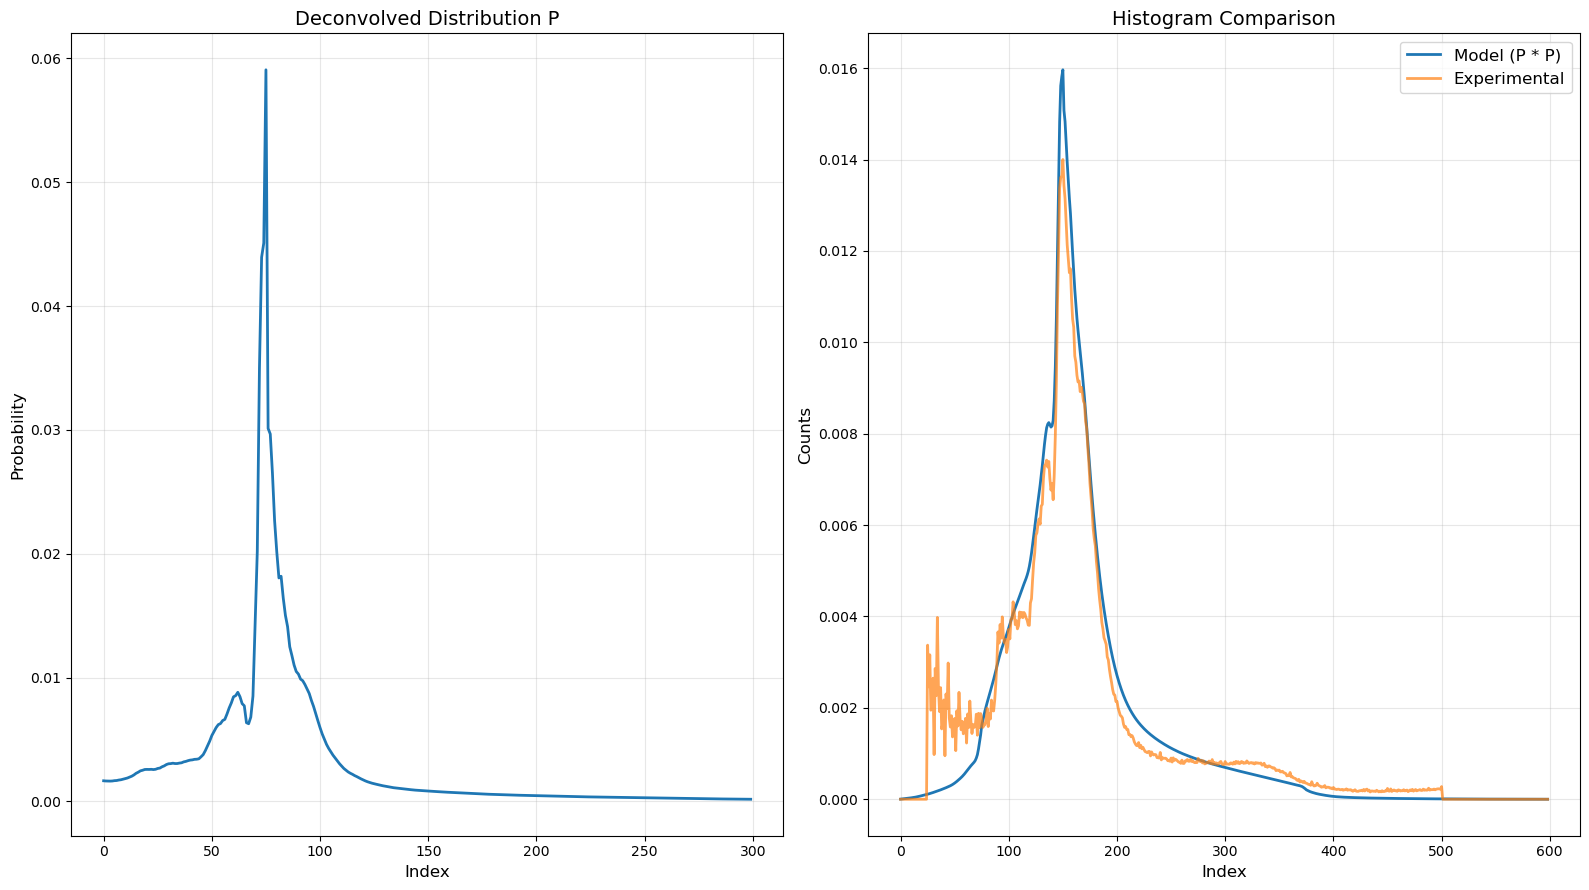

In [119]:
deconv.plot()

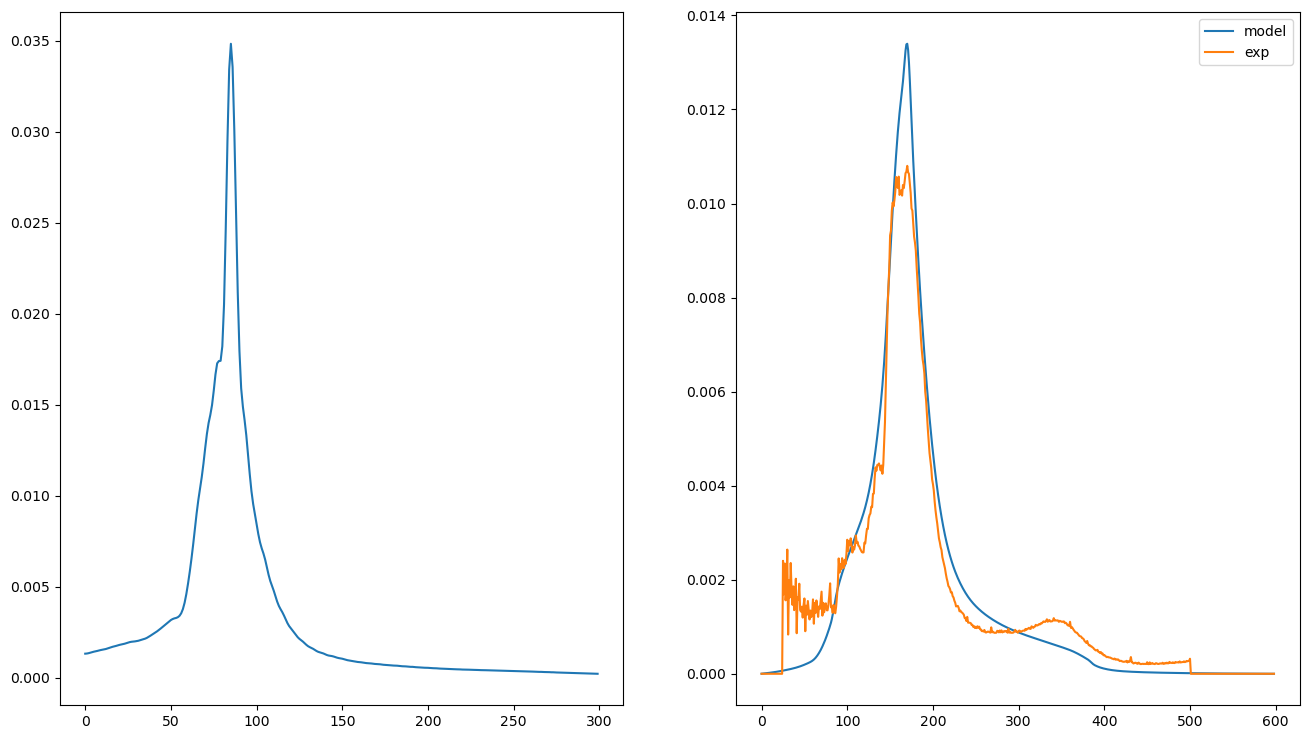

In [308]:
Q = hist.reshape(-1, 1)
N = len(Q)
k = N // 2 + 1
lamb = 14
x = np.arange(0, k, 1)
P_init = spy.stats.norm.pdf(x, loc=73, scale=10)
P_init /= P_init.sum()

center = np.argmax(Q) // 2
x = np.arange(0, k)
sigma = 5
weights = (center - x) ** 2
weights = weights / np.max(weights)


def loss(P, Q, lamb, weights):
    reg = lamb * np.dot(P**2, weights)
    # reg = lamb * np.sum(P ** 2)
    loss = np.sum((Q - np.convolve(P, P).reshape(-1, 1)) ** 2) + reg
    return loss


bounds = [(0, 1) for i in range(k)]
result = spy.optimize.minimize(
    loss,
    bounds=bounds,
    args=(Q, lamb, weights),
    x0=P_init,
    method="SLSQP",
    constraints={"type": "eq", "fun": lambda p: np.sum(p) - 1},
    tol=1e-30,
)


fig, axs = plt.subplots(1, 2, figsize=(16, 9))

axs[0].plot(result.x)
axs[1].plot(np.convolve(result.x, result.x), label="model")
axs[1].plot(hist, label="exp")
plt.legend()

In [303]:
import os

dir_path = os.path.dirname(BAM_PATH)
basename = os.path.basename(dir_path)
outdir = os.path.join(dir_path, f"{basename}_errors")


def save_optimization(results, outdir):
    basename = os.path.basename(outdir)
    errors_file = os.path.join(outdir, f"{basename}.csv")
    np.savetxt(
        errors_file,
        results.x,
        delimiter=",",
        header="Linker_error_probabilities",
        comments="",
    )


save_optimization(result, outdir)

In [6]:
class BamFileIterator:
    def __init__(
        self,
        pysam_path,
        chromosome,
        window_size=4000,
        start=0,
        stop=None,
        step=3500,
        device="cpu",
    ):
        self.al_file = pysam.AlignmentFile(pysam_path)
        self.chromosome = chromosome
        self.window_size = window_size
        self.step = step
        self.__initial_start = start
        self.__stop = (
            stop
            if stop
            else dict(zip(self.al_file.references, self.al_file.lengths))[chromosome]
        )
        self.device = device

    def __len__(self):
        return (self.stop - self.initial_start) // self.step

    def __getitem__(self, idx):
        if idx < 0 or idx >= len(self):
            raise IndexError(f"Index {idx} out of range [0, {len(self)})")
        cur_start = self.initial_start + idx * self.step
        cur_stop = cur_start + self.window_size
        if cur_stop > self.stop:
            cur_stop = self.stop
        if cur_start >= self.stop:
            return {
                "start": torch.tensor([]).view(-1, 1),
                "end": torch.tensor([]).view(-1, 1),
                "id": [],
            }
        records = list(self.al_file.fetch(self.chromosome, cur_start, cur_stop))
        paired_records = self._collect_paired_reads(records)
        items = {
            "start": torch.tensor(
                list(map(lambda x: x[0].reference_start, paired_records))
            ).view(-1, 1),
            "end": torch.tensor(
                list(map(lambda x: x[1].reference_end, paired_records))
            ).view(-1, 1),
            "id": list(map(lambda x: x[0].qname, paired_records)),
        }
        return items

    @property
    def initial_start(self):
        return self.__initial_start

    @property
    def stop(self):
        return self.__stop

        self.chromo_len = dict(zip(self.al_file.references, self.al_file.lengths))[
            chromosome
        ]

    def __del__(self):
        self.al_file.close()

    def __iter__(self):
        self.cur_start = self.initial_start
        self.cur_stop = self.cur_start + self.window_size
        self.stop_iter = False
        return self

    def __next__(self):
        if self.stop_iter == True:
            raise StopIteration

        if self.cur_stop >= self.stop:
            self.stop_iter = True

        records = list(
            self.al_file.fetch(self.chromosome, self.cur_start, self.cur_stop)
        )
        paired_records = self._collect_paired_reads(records)
        items = {
            "start": torch.tensor(
                list(map(lambda x: x[0].reference_start, paired_records))
            ).view(-1, 1),
            "end": torch.tensor(
                list(map(lambda x: x[1].reference_end, paired_records))
            ).view(-1, 1),
            "id": list(map(lambda x: x[0].qname, paired_records)),
        }
        self.cur_start += self.step
        self.cur_stop = self.cur_start + self.window_size
        return items

    def _collect_paired_reads(self, records):
        read_pairs = defaultdict(dict)
        valid_pairs = []

        for read in records:
            name = read.query_name
            if read.is_read1:
                read_pairs[name]["R1"] = read
            elif read.is_read2:
                read_pairs[name]["R2"] = read

        # Отбираем только полные пары
        for name, pair in read_pairs.items():
            if "R1" in pair and "R2" in pair:
                valid_pairs.append((pair["R1"], pair["R2"]))
        return valid_pairs

In [7]:
import copy

import torch


class EMModel:
    def __init__(
        self,
        errors,
        dyad_dist,
        max_iter=500,
        reg_coef=0,
        tol=0.0001,
        device="cpu",
        alpha=0.5,
    ):
        self.device = device
        self.errors = errors.to(device)
        self.dyad_dist = dyad_dist
        self.max_iter = max_iter
        self.reg_coef = reg_coef
        self.tol = tol
        self.alpha = alpha

    @property
    def nreads(self):
        return len(self.starts)

    @property
    def ndyads(self):
        return len(self.dyads)

    def __validate_cords(self, cords):
        return cords.to(self.device)

    def __validate_dyads(self, dyads=None):
        if dyads is None:
            dyads = (
                torch.arange(
                    self.starts.min(),
                    self.stops.max() + 1,
                    self.dyad_dist,
                    device=self.device,
                )
                .int()
                .reshape(-1, 1)
            )
        return dyads

    def __validate_weights(self, weights=None):
        if weights is None:
            weights = torch.rand(self.ndyads, dtype=float, device=self.device).reshape(
                -1, 1
            )
            weights /= weights.sum()
        return weights

    def __create_probs_matrix(self, dyads):
        # dyads имеет размерность [n, 1]
        n_dyads = dyads.shape[0]
        n_reads = self.nreads

        # Используем broadcasting без создания промежуточных тензоров ones
        left_diff = dyads - self.starts.view(1, -1)  # [n, nreads]
        right_diff = self.stops.view(1, -1) - dyads  # [n, nreads]

        L_index = self.__insert_probs_to_matrix(left_diff, self.errors)
        R_index = self.__insert_probs_to_matrix(right_diff, self.errors)

        return (L_index * R_index).T

    def __create_grid_probs(self):
        potential_dyads = torch.arange(
            self.starts.min(), self.stops.max() + 1, device=self.device
        ).reshape(
            -1, 1
        )  # [grid_size, 1]

        probs = torch.log(self.__create_probs_matrix(potential_dyads) + 1e-50)
        return probs

    def __insert_probs_to_matrix(self, idx_matrix, errors):
        # idx_matrix: [n, nreads]

        # Округляем до целых индексов
        idx = idx_matrix.round().long()

        # Создаем маску валидных индексов
        valid_mask = (idx >= 0) & (idx < len(errors))

        # Быстрое заполнение через advanced indexing
        result = torch.zeros_like(idx_matrix, dtype=float) + 1e-50

        # Получаем индексы для валидных элементов
        valid_indices = idx[valid_mask]

        # Заполняем значения
        result[valid_mask] = errors[valid_indices]

        return result

    def e_step(self):
        self.probs_matrix = self.__create_probs_matrix(self.dyads)
        self.Hij = (self.probs_matrix * self.weights.T) / (
            self.probs_matrix @ self.weights
        )
        if self.Hij.isnan().any():
            raise ValueError("Has None")

    def m_step(self):
        self.dyads = (
            self.starts.min()
            + torch.argmax(self.grid_probs.T @ self.Hij, dim=0, keepdim=True).T
        )
        self.weights = self.Hij.sum(0, keepdim=True).T
        self.weights = self.weights / self.weights.sum() - self.reg_coef
        self.weights[self.weights < 0] = 0
        self.weights /= self.weights.sum()
        if (self.weights == 0).all() or self.weights.isnan().all():
            raise ValueError("all weights = 0. It seems reg_coef is too high")

    def delete_components(self):
        keep_alive_mask = (self.weights > 0).bool().reshape(-1, 1)
        self.weights = self.weights[keep_alive_mask].reshape(-1, 1)
        self.weights /= self.weights.sum()
        self.dyads = self.dyads[keep_alive_mask].reshape(-1, 1)
        self.probs_matrix = self.__create_probs_matrix(self.dyads)

    def to(self, device):
        """Move model to specified device"""
        self.device = device
        self.starts = self.starts.to(device)
        self.stops = self.stops.to(device)
        self.errors = self.errors.to(device)
        self.dyads = self.dyads.to(device)
        self.weights = self.weights.to(device)
        if self.probs_matrix is not None:
            self.probs_matrix = self.probs_matrix.to(device)
        if self.Hij is not None:
            self.Hij = self.Hij.to(device)

    def get_params(self):
        params = {
            "L": self.starts,
            "R": self.stops,
            "errors": self.errors,
            "dyad_dist": self.dyad_dist,
            "max_iter": self.max_iter,
            "reg_coef": self.reg_coef,
            "tol": self.tol,
            "dyads": self.dyads,
            "weights": self.weights,
            "device": self.device,
        }
        return params

    def logLH(self):
        lh = (
            torch.log((self.probs_matrix * self.weights.T).sum(axis=0)).sum()
            - self.reg_coef * torch.log(self.weights).sum()
        )
        return lh

    def fit(self, starts, stops, dyads=None, weights=None):
        self.starts = self.__validate_cords(starts)
        self.stops = self.__validate_cords(stops)
        self.dyads = self.__validate_dyads(dyads)
        self.probs_matrix = self.__create_probs_matrix(self.dyads)
        self.grid_probs = self.__create_grid_probs()
        self.weights = self.__validate_weights(weights)
        self.e_step()

        nweights = []

        prev_lh = -100000
        prev_sliding_mean = -100000
        lh_loss = []
        sliding_mean_list = []

        for i in range(self.max_iter):
            self.e_step()
            self.m_step()
            self.delete_components()

            nweights.append(len(self.weights))

            cur_lh = self.logLH()
            lh_loss.append(cur_lh.item())

            # Правильное экспоненциальное скользящее среднее
            if i == 0:
                sliding_mean = cur_lh  # Первое значение равно самому значению
            else:
                sliding_mean = (
                    self.alpha * cur_lh + (1 - self.alpha) * prev_sliding_mean
                )

            sliding_mean_list.append(sliding_mean.item())

            # Обновляем предыдущие значения
            prev_lh = cur_lh
            delta_sliding_mean = sliding_mean - prev_sliding_mean
            prev_sliding_mean = sliding_mean

            if delta_sliding_mean < self.tol:
                self.e_step()
                return lh_loss, sliding_mean_list, True, nweights
        self.e_step()
        return lh_loss, sliding_mean_list, False, nweights


class StochasticEMMOdel(EMModel):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def m_step(self):
        # Оптимизируем выборку
        stochastic_res = self.__sample_multinomial_vectorized_torch()

        # Оптимизируем вычисление dyads
        # Используем einsum или matmul для более эффективного умножения
        weighted_sum = torch.matmul(self.grid_probs.T, stochastic_res)
        max_indices = torch.argmax(weighted_sum, dim=0, keepdim=True).T
        self.dyads = self.starts.min() + max_indices

        # Оптимизируем вычисление weights
        self.weights = stochastic_res.sum(0, keepdim=True).T

        # Нормализация с регуляризацией за один проход
        weights_sum = self.weights.sum()
        if weights_sum != 1:
            self.weights = self.weights / weights_sum - self.reg_coef
        else:
            self.weights = self.weights - self.reg_coef

        # Быстрая замена отрицательных значений
        self.weights = torch.where(
            self.weights < 0, torch.tensor(0.0, device=self.device), self.weights
        )
        self.weights = self.weights / self.weights.sum()

    def __sample_multinomial_vectorized_torch(self):
        # Быстрая проверка на NaN
        if torch.isnan(self.Hij).any():
            raise ValueError("Hij matrix contains nan")

        # Оптимизированная мультиномиальная выборка
        # Используем torch.multinomial с оптимизациями
        samples = torch.multinomial(self.Hij, num_samples=1).squeeze(-1)

        # Более эффективное создание one-hot encoding
        # Используем scatter_ вместо one_hot для скорости
        n_classes = self.Hij.shape[-1]
        stochastic_res = torch.zeros(
            (samples.shape[0], n_classes), device=self.device, dtype=torch.double
        )
        stochastic_res.scatter_(1, samples.unsqueeze(-1), 1.0)

        return stochastic_res

In [8]:
def make_df(model):
    if model.device != "cpu":
        model.to("cpu")
    df = pd.DataFrame({"start": model.starts.flatten(), "stop": model.stops.flatten()})
    df["dyads"] = model.dyads[model.Hij.argmax(1)]
    df["template|dyad"] = model.Hij.max(1)[0]
    return df


def make_occupancy(starts, stops):
    min_value = starts.min()
    max_value = stops.max()
    x = np.arange(min_value, max_value + 1)
    occ = np.zeros_like(x)
    for start, stop in zip(starts, stops):
        occ[start - min_value : stop - min_value + 1] += 1
    return x, occ


def make_template_occupancy(dyads, template):
    min_value = dyads.min()
    max_value = dyads.max()
    x = np.arange(min_value - len(template), max_value + len(template), dtype=float)
    occ = np.zeros_like(x)
    for dyad in dyads:
        start_pos = dyad - len(template) // 2 - min_value + len(template)
        occ[start_pos : start_pos + len(template)] += template
    return (
        x[len(template) // 2 : -len(template) // 2],
        occ[len(template) // 2 : -len(template) // 2],
    )


def fit_model_template(errors, size=100000):
    vals = np.arange(len(errors))

    # Генерируем случайные значения
    random_lefts = -np.random.choice(vals, size=size, p=errors)
    random_rights = np.random.choice(vals, size=size, p=errors)

    # Определяем диапазон
    all_values = np.concatenate([random_lefts, random_rights + 1])
    min_val = int(min(all_values)) - 50
    max_val = int(max(all_values)) + 50

    # Создаем массив для накопления
    diff_array = np.zeros(max_val - min_val + 2, dtype=np.int64)

    # Заполняем разности (векторизованная операция)
    left_indices = random_lefts - min_val
    right_indices = random_rights + 1 - min_val

    # Используем bincount для быстрого подсчета
    left_counts = np.bincount(left_indices.astype(int), minlength=len(diff_array))
    right_counts = np.bincount(right_indices.astype(int), minlength=len(diff_array))

    diff_array = left_counts - right_counts

    # Вычисляем кумулятивную сумму
    result = np.cumsum(diff_array) / size

    return result


def fit_regcoef_window(model, templates, reg_coef_grid, model_template):
    cur_rmsd = []
    L, R = templates["start"], templates["end"]
    for reg_coef in reg_coef_grid:
        model.reg_coef = reg_coef
        try:
            model.fit(L, R)
        except Exception as error:
            print(error, reg_coef)
            cur_rmsd.append(np.nan)
            continue
        df = make_df(model)
        x, oc = make_occupancy(df.start.to_numpy(), df.stop.to_numpy())
        bar_counter = Counter(df.dyads.value_counts().to_dict())
        x_bars = [bar_counter[cord] for cord in x]
        conv = np.convolve(x_bars, model_template, mode="same")
        rmsd = ((oc - conv) ** 2).sum() / len(x)
        cur_rmsd.append(rmsd)
    return cur_rmsd


def fit_regcoef(
    model, iterator, nfits, reg_coef_grid, model_template: list = None, verbose=True
):
    total_rmsd = []
    windows_index = np.random.randint(0, len(iterator), size=nfits)
    for i in tqdm(windows_index, total=nfits):
        templates = iterator[i]
        cur_rmsd = fit_regcoef_window(model, templates, reg_coef_grid, model_template)
        total_rmsd.append(cur_rmsd)
    return total_rmsd

In [59]:
import copy
from collections import Counter

import numpy as np
from tqdm.auto import tqdm


def fit_regcoef_parallel(
    model,
    iterator,
    nfits,
    reg_coef_grid,
    model_template,
    verbose=True,
    n_workers=None,
    method="auto",
):
    """
    Автоматически выбирает метод параллелизации

    Parameters:
    -----------
    method : 'auto', 'joblib', 'multiprocessing', 'sequential'
    """

    # Определяем worker функцию
    def worker(templates):
        model_copy = copy.deepcopy(model)

        cur_rmsd = []
        L, R = templates["start"], templates["end"]

        for reg_coef in reg_coef_grid:
            model_copy.reg_coef = reg_coef
            try:
                model_copy.fit(L, R)
            except Exception as error:
                print(error, reg_coef)
                cur_rmsd.append(np.nan)
                continue

            df = make_df(model_copy)
            x, oc = make_occupancy(df.start.to_numpy(), df.stop.to_numpy())
            bar_counter = Counter(df.dyads.value_counts().to_dict())
            x_bars = [bar_counter[cord] for cord in x]
            conv = np.convolve(x_bars, model_template, mode="same")
            rmsd = ((oc - conv) ** 2).sum() / len(x)
            cur_rmsd.append(rmsd)

        return cur_rmsd

    windows_index = np.random.randint(0, len(iterator), size=nfits)
    templates_list = [iterator[i] for i in windows_index]

    # Автоматический выбор метода
    if method == "auto":
        try:
            # Пробуем использовать joblib (работает везде)
            from joblib import Parallel, delayed

            method = "joblib"
        except ImportError:
            try:
                # Пробуем multiprocessing
                from multiprocessing import Pool

                method = "multiprocessing"
            except:
                method = "sequential"

    # Выполняем выбранным методом
    if method == "joblib":
        from joblib import Parallel, delayed

        if n_workers is None or n_workers == -1:
            import multiprocessing as mp

            n_workers = max(1, mp.cpu_count() - 1)

        if verbose:
            print(f"Using joblib with {n_workers} workers")
            total_rmsd = Parallel(n_jobs=n_workers, verbose=10)(
                delayed(worker)(templates) for templates in templates_list
            )
        else:
            total_rmsd = Parallel(n_jobs=n_workers)(
                delayed(worker)(templates) for templates in templates_list
            )

    elif method == "multiprocessing":
        from multiprocessing import Pool, cpu_count

        if n_workers is None:
            n_workers = max(1, cpu_count() - 1)

        if verbose:
            print(f"Using multiprocessing with {n_workers} workers")
            with Pool(processes=n_workers) as pool:
                total_rmsd = list(
                    tqdm(
                        pool.imap(worker, templates_list),
                        total=nfits,
                        desc="Processing windows",
                    )
                )
        else:
            with Pool(processes=n_workers) as pool:
                total_rmsd = pool.map(worker, templates_list)

    else:  # sequential
        if verbose:
            print("Using sequential processing")
            total_rmsd = []
            for templates in tqdm(templates_list, desc="Processing windows"):
                total_rmsd.append(worker(templates))
        else:
            total_rmsd = [worker(templates) for templates in templates_list]

    return total_rmsd

In [33]:
chrom_lengths = dict(zip(BAM_FILE.references, BAM_FILE.lengths))
chrom_lengths
# list(filter(lambda x: x.startswith("NC"), chrom_lengths.keys()))

{'NC_004354.4': 23542271,
 'NW_001845990.1': 1625,
 'NW_001846257.1': 1311,
 'NW_001845957.1': 1709,
 'NW_001845953.1': 1713,
 'NW_001845561.1': 2464,
 'NW_001846366.1': 1258,
 'NW_001845373.1': 2956,
 'NW_001845450.1': 2781,
 'NW_001845573.1': 2432,
 'NW_001845748.1': 2078,
 'NW_001846054.1': 1516,
 'NW_001845911.1': 1793,
 'NW_001845815.1': 1956,
 'NW_001847283.1': 1004,
 'NW_001846524.1': 1195,
 'NW_001846034.1': 1541,
 'NW_001845796.1': 1978,
 'NW_001845363.1': 2999,
 'NW_001846907.1': 1092,
 'NW_001847086.1': 1049,
 'NW_001845656.1': 2259,
 'NW_001846098.1': 1453,
 'NW_001846254.1': 1312,
 'NW_001845874.1': 1869,
 'NW_001846461.1': 1220,
 'NW_001845508.1': 2591,
 'NW_001845939.1': 1737,
 'NW_001846019.1': 1560,
 'NW_001845489.1': 2639,
 'NW_001845801.1': 1970,
 'NW_001845871.1': 1870,
 'NW_001845818.1': 1947,
 'NW_001845718.1': 2113,
 'NW_001845807.1': 1964,
 'NW_001846122.1': 1424,
 'NW_001846013.1': 1575,
 'NW_001846304.1': 1283,
 'NW_001845883.1': 1843,
 'NW_001846895.1': 1097,

In [34]:
templates1 = next(
    iter(BamFileIterator(BAM_PATH, "NC_004354.4", start=2000000, window_size=10000))
)
templates2 = next(
    iter(BamFileIterator(BAM_PATH, "NC_004354.4", start=23000 // 2, window_size=3000))
)
templates3 = next(
    iter(BamFileIterator(BAM_PATH, "NC_004354.4", start=26000 // 2, window_size=3000))
)

In [35]:
i = BamFileIterator(BAM_PATH, "NC_004354.4", start=2000000, window_size=5000)

In [36]:
L1 = templates1["start"]
R1 = templates1["end"]

# L2 = templates2["start"]
# R2 = templates2["end"]

# L3 = templates3["start"]
# R3 = templates3["end"]

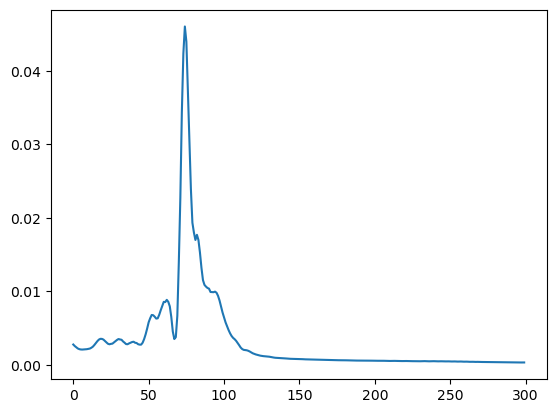

In [37]:
loaded_data = np.loadtxt(
    "../data/reads/D_melanogaster_mnase/SRR8766785/SRR8766785_errors/SRR8766785_errors.csv",  # имя файла (то же самое, что использовали при сохранении)
    delimiter=",",  # тот же разделитель
    skiprows=1,  # пропускаем заголовок (header)
)

errors = torch.from_numpy(loaded_data)
# z = torch.zeros(100)
# errors = torch.concat([errors, z])
plt.plot(errors)

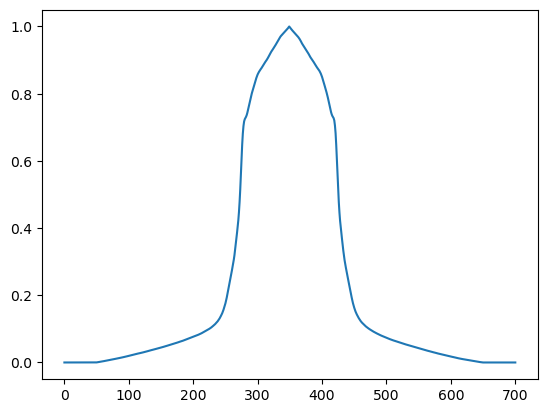

In [38]:
c = fit_model_template(errors)
plt.plot(c)

In [39]:
import cProfile


def test_time():
    model = StochasticEMMOdel(
        errors, 5, device="cpu", reg_coef=2 / len(L1), max_iter=10
    )
    res = model.fit(L1, R1)
    return res


# m = test_time()
#

# cProfile.run('test_time()')

In [50]:
import copy

In [58]:
cop = copy.deepcopy(model)
cop.Hij


AttributeError: 'StochasticEMMOdel' object has no attribute 'Hij'

In [60]:
model = StochasticEMMOdel(
    errors, 10, device="cuda", tol=0.5, max_iter=1000, alpha=0.05, reg_coef=0.001
)

In [61]:
torch.cuda.empty_cache()
grid = np.linspace(0.001, 0.05, 20)

regcoef_fit = fit_regcoef_parallel(
    model, i, 100, grid, c, n_workers=16
)

Using joblib with 16 workers


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:   23.3s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:   31.9s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:   36.6s
[Parallel(n_jobs=16)]: Done  40 tasks      | elapsed:   46.8s
[Parallel(n_jobs=16)]: Done  53 tasks      | elapsed:   55.6s
[Parallel(n_jobs=16)]: Done  66 tasks      | elapsed:  1.1min
[Parallel(n_jobs=16)]: Done  80 out of 100 | elapsed:  1.3min remaining:   19.8s
[Parallel(n_jobs=16)]: Done  91 out of 100 | elapsed:  1.4min remaining:    8.6s


cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.024210526315789474
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.026789473684210526
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.02936842105263158
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.031947368421052634
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.03452631578947368
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.03710526315789474
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.03968421052631579
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.04226315789473684
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.0448421052631579
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.04742105263157895
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.05
c

[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:  1.6min finished


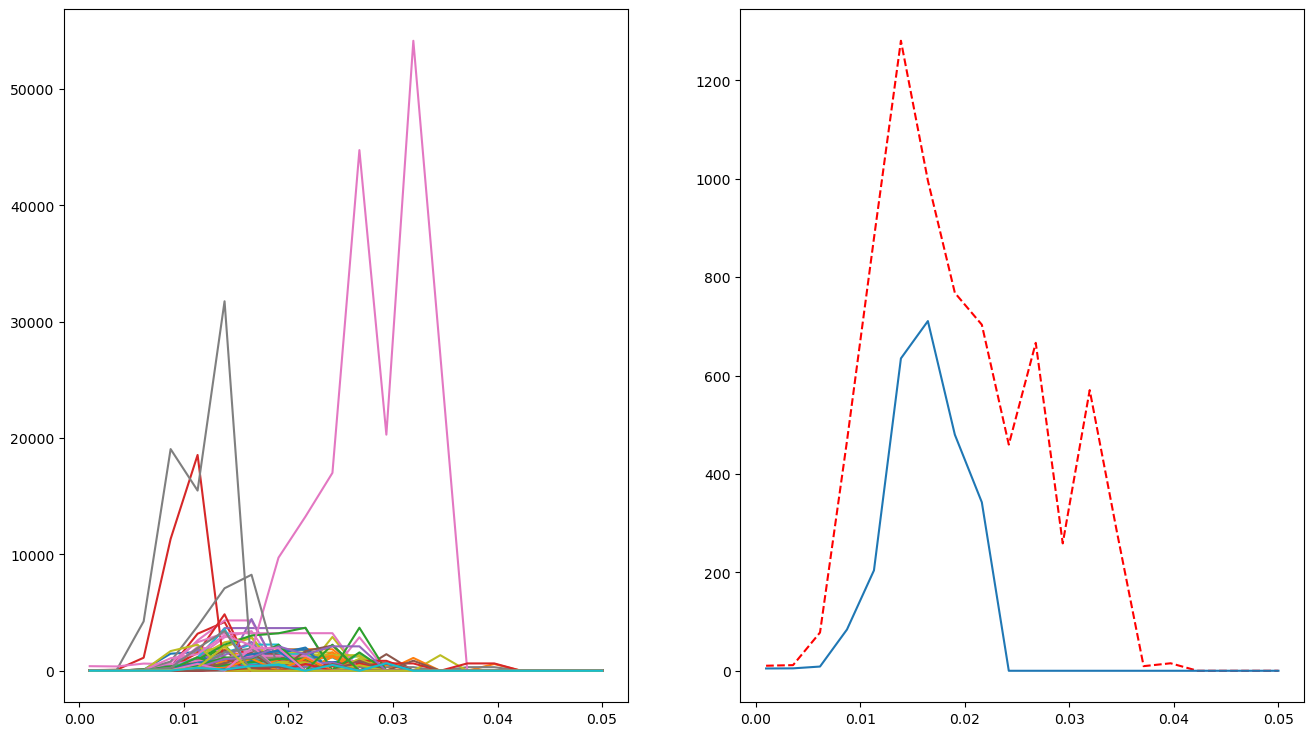

In [62]:
x = grid
vals = np.asarray(regcoef_fit)
vals[np.isnan(vals)] = 0
mean_rmsd = vals.mean(axis=0)
median_rmsd = np.median(vals, axis=0)

fig, axs = plt.subplots(1, 2, figsize=(16, 9))

for v in vals:
    axs[0].plot(x, v)

axs[1].plot(x, mean_rmsd, "--", color="red")
axs[1].plot(x, median_rmsd)

In [57]:
vals[0]

array([ 2.78735233,  2.67363204,  2.75718355,  2.61410391,  2.9145854 ,
       19.86626699,  8.88774096, 11.74812104,  5.64491665, 12.07007774])

<Axes: >

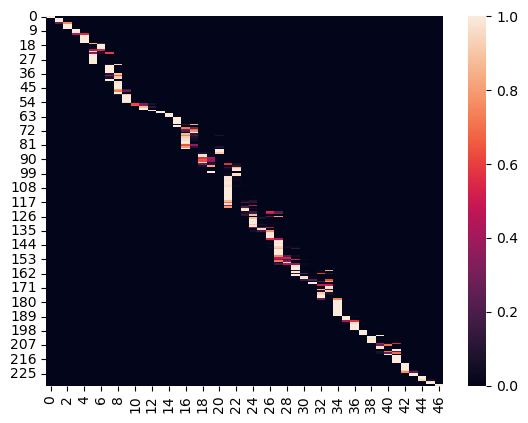

In [83]:
model = StochasticEMMOdel(
    errors, 2, device="cuda", tol=1e-15, max_iter=1000, alpha=0.05, reg_coef=0.002
)
# model.reg_coef = 0.006
res = model.fit(i[15]["start"], i[15]["end"])

sns.heatmap(model.Hij.cpu())

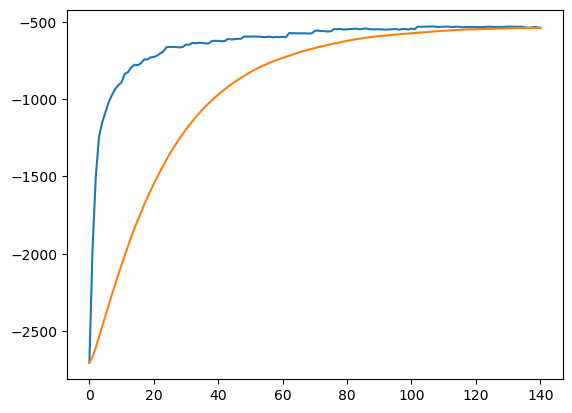

In [84]:
plt.plot(res[0])
plt.plot(res[1])

In [85]:
df = make_df(model)

3.023171635667698


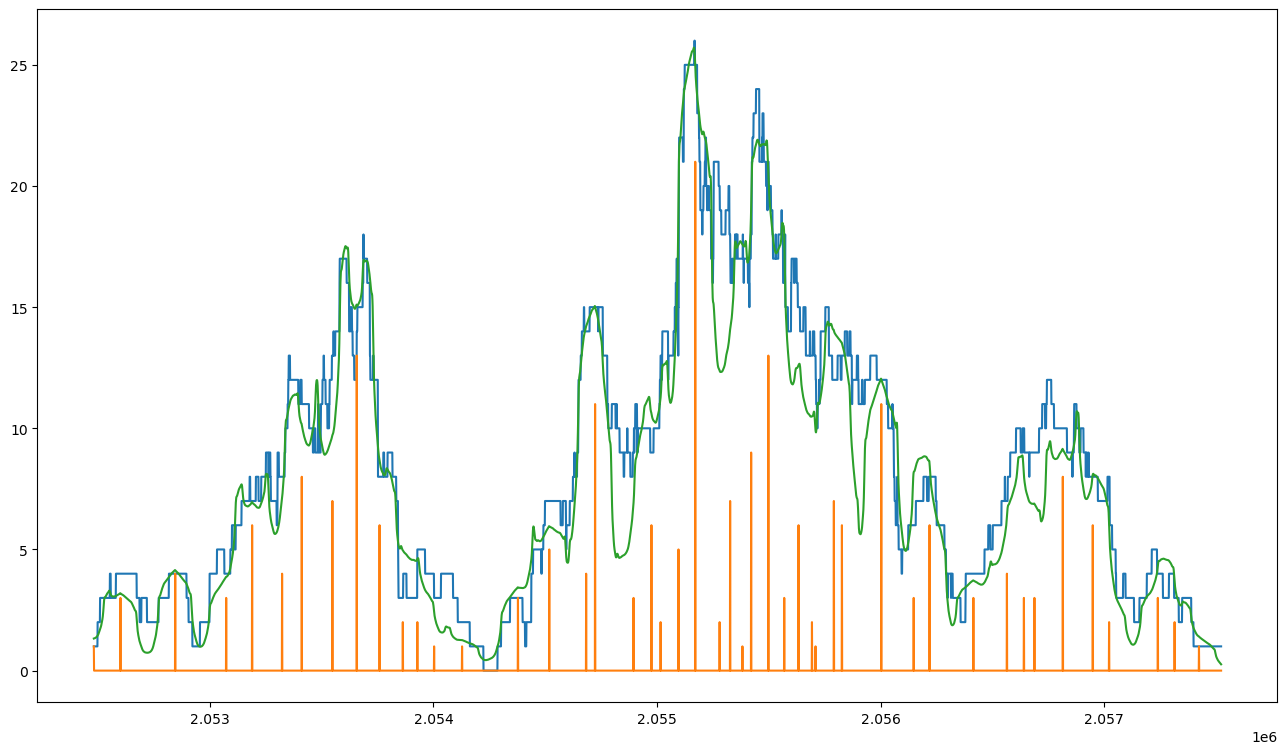

cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.021631578947368422
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.024210526315789474
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.026789473684210526
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.02936842105263158
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.031947368421052634
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.03452631578947368
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.03710526315789474
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.03968421052631579
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.04226315789473684
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.0448421052631579
cannot sample n_sample > prob_dist.size(-1) samples without replacement 0.047

In [86]:
plt.figure(figsize=(16, 9))
x, oc = make_occupancy(df.start.to_numpy(), df.stop.to_numpy())

bar_counter = Counter(df.dyads.value_counts().to_dict())
x_bars = [bar_counter[cord] for cord in x]

plt.plot(x, oc)
plt.plot(x, x_bars)

conv = np.convolve(x_bars, c, mode="same")
plt.plot(x, conv)

rmsd = ((oc - conv) ** 2).sum() / len(x)
print(rmsd)

In [48]:
df = make_df(model)

In [49]:
df.groupby("dyads").count()

,start,stop,template|dyad
dyads,,,
2035028,1,1,1
2035136,5,5,5
2035316,4,4,4
2035508,3,3,3
2035603,4,4,4
2035731,7,7,7
2035763,2,2,2
2035880,3,3,3
2035984,3,3,3


In [ ]:
m1 = train_model(StochasticEMMOdel, L1, R1, errors, params, 30, 3)
m2 = train_model(StochasticEMMOdel, L2, R2, errors, params, 30, 3)
m3 = train_model(StochasticEMMOdel, L3, R3, errors, params, 30, 3)

In [ ]:
m1.to("cpu")
m2.to("cpu")
m3.to("cpu")

In [ ]:
# rmsd1 = grid_reg_coef(model1, np.linspace(0.0001, 1, 10))

# m2 = grid_search(model1, np.linspace(0.0001, 1, 10))

# m3 = grid_search(model1, np.linspace(0.0001, 1, 10))

In [ ]:
m3.Hij.max(1)[0].shape

In [ ]:
df1, df2, df3 = make_df(m1), make_df(m2), make_df(m3)
df1["label"] = 1
df2["label"] = 2
df3["label"] = 3

df = pd.concat([df1, df2, df3])

In [ ]:
df1

In [ ]:
x1, occ1 = make_occupancy(L1.numpy().flatten(), R1.numpy().flatten())
x2, occ2 = make_occupancy(L2.numpy().flatten(), R2.numpy().flatten())
x3, occ3 = make_occupancy(L3.numpy().flatten(), R3.numpy().flatten())

template_x1, templates_occ1 = make_template_occupancy(
    df1.dyads.to_numpy(), ExoNucTemplate().nuc_template
)
template_x2, templates_occ2 = make_template_occupancy(
    df2.dyads.to_numpy(), ExoNucTemplate().nuc_template
)
template_x3, templates_occ3 = make_template_occupancy(
    df3.dyads.to_numpy(), ExoNucTemplate().nuc_template
)

c1 = Counter(df1.dyads.values)
bars1 = [c1[i] for i in x1]

c2 = Counter(df2.dyads.values)
bars2 = [c2[i] for i in x2]

c3 = Counter(df3.dyads.values)
bars3 = [c3[i] for i in x3]

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(16, 9), sharex=True, sharey=False)


axs[0].plot(template_x1, templates_occ1)
axs[0].plot(x1, occ1)
axs[0].plot(x1, bars1)
axs[0].grid()

axs[1].plot(template_x2, templates_occ2)
axs[1].plot(x2, occ2)
axs[1].plot(x2, bars2)
axs[1].grid()

axs[2].plot(template_x3, templates_occ3)
axs[2].plot(x3, occ3)
axs[2].plot(x3, bars3)
axs[2].grid()

# fig.savefig("../data/figs/fit_exo_figs/tmp/convergence.png")

In [ ]:
m2.Hij.argmax(0).shape

In [ ]:
m2.dyads.shape

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9), sharex=True, sharey=True)


ax.plot(template_x1, templates_occ1)
ax.plot(x1, occ1)
ax.plot(x1, bars1)
ax.grid()

plt.xlim(20000, 22500)

In [ ]:
chromosomes = ["NC_001136.10"]

In [ ]:
for chromosome in chromosomes:
    bam_iterator = BamFileIterator(
        args.input, chromosome, window_size=args.window_size, step=args.step
    )

    for idx, batch in enumerate(bam_iterator):
        starts, ends = batch["start"], batch["end"]
        model = StochasticEMMOdel(
            starts,
            ends,
            errors,
            args.dyad_dist,
            reg_coef=0,
            max_iter=args.max_iter,
            device=args.device,
        )
        best_model = optimize_reg_coef(
            model, args.train_iter, args.max_successful_trains
        )
        best_model.to("cpu")

In [ ]:
model = StochasticEMMOdel(
    starts, ends, errors, 1, reg_coef=0, max_iter=600, device="cpu"
)

In [ ]:
device = "cuda"

In [ ]:
bam_iterator = BamFileIterator(
    BAM_PATH, "NC_001136.10", window_size=3000, start=157 * 300, device=device
)


for idx, batch in enumerate(bam_iterator):
    if idx == 154:
        starts = batch["start"]
        ends = batch["end"]
        params = {"dyad_dist": 1, "device": device}

        best_model = optimize_reg_coef(
            StochasticEMMOdel,
            starts,
            ends,
            errors,
            params,
            50,
            2,
        )

        df = make_df(best_model)
        break

In [ ]:
best_model.dyads.shape

In [ ]:
best_model.Hij.shape

In [ ]:
(ends - starts).argmax()

In [ ]:
len(errors)

In [ ]:
model = StochasticEMMOdel(starts, ends, errors, 1, reg_coef=0.0001)

In [ ]:
model.run()

In [ ]:
sns.heatmap(model.Hij)

In [ ]:
model.weights.shape

In [ ]:
starts.min()

In [ ]:
starts.max()

In [ ]:
d = torch.arange(starts.min(), starts.max() + 1, 1)

In [ ]:
l = d - starts[1197].float()
m_l = ((l >= 0) & (l < len(errors))).bool()
l[~m_l] = 0
l[m_l] = errors[l[m_l].int()].float()

r = ends[1197].float() - d
m_r = ((r >= 0) & (r < len(errors))).bool()
r[~m_r] = 0
r[m_r] = errors[r[m_r].int()].float()

In [ ]:
plt.plot(l)
plt.plot(r)

p = l * r
p /= p.sum()
plt.plot(p)

In [ ]:
starts[1197]

In [ ]:
bam_iterator = BamFileIterator(
    BAM_PATH, "NC_001136.10", window_size=3000, device="cuda:0"
)


for batch in bam_iterator:
    starts = batch["start"]
    ends = batch["end"]
    break

In [ ]:
starts.device

In [ ]:
torch.cuda.empty_cache()

In [ ]:
batch["start"].clone().to("cuda:0")

In [ ]:
best_model.dyads.isnan().any()

In [ ]:
sns.heatmap(best_model.Hij)

In [ ]:
best_model.probs_matrix.shape

In [ ]:
best_model.dyads.shape

In [ ]:
best_model.Hij.shape

In [ ]:
best_model.dyad_dist

In [ ]:
best_model.e_step()

In [ ]:
best_model.Hij.shape

In [ ]:
best_model.starts.to("cuda:0")

In [ ]:
best_model.starts.shape

In [ ]:
best_model.stops.shape

In [ ]:
plt.plot(*make_occupancy(starts.numpy().flatten(), stops.numpy().flatten()))